# Itau Quant Challenge 2025 - Pipeline End-to-End

Este notebook executa o processo completo do repositorio, explicando cada etapa e salvando artefatos em `reports/`.

Etapas:
- Carregar configuracao e dados
- Rodar backtest base e exibir KPIs
- Walk-forward validation
- Heatmaps de sensibilidade de parametros
- Stress de custos de transacao
- Capacity curve
- (Opcional) PDF consolidado do relatorio


In [1]:
import os
for env in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[env] = "1"
os.environ["PYTHONHASHSEED"] = "0"

In [2]:
import features, importlib, sys
print("features from:", features.__file__)
import features.tda as tda, features.factors as fac
print("has get_alphas_from_cfg?", hasattr(fac, "get_alphas_from_cfg"))
print("TFIParams.from_config?", hasattr(tda.TFIParams, "from_config"))
print(sys.path[:3])


features from: C:\Users\Douglas\Documents\itau-quant-challenge-2025\src\features\__init__.py
has get_alphas_from_cfg? True
TFIParams.from_config? True
['C:\\Users\\Douglas\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'C:\\Users\\Douglas\\AppData\\Local\\Programs\\Python\\Python312\\DLLs', 'C:\\Users\\Douglas\\AppData\\Local\\Programs\\Python\\Python312\\Lib']


In [3]:
# Setup
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

import os; os.environ["REGIME_GAIN"] = "2"
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
assert (ROOT / 'src').exists(), 'Execute a partir do repo root ou da pasta notebooks/'
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
%matplotlib inline

REPORTS_DIR = ROOT / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
print('Repo root:', ROOT)
print('Reports dir:', REPORTS_DIR)

Repo root: c:\Users\Douglas\Documents\itau-quant-challenge-2025
Reports dir: c:\Users\Douglas\Documents\itau-quant-challenge-2025\reports


## Configuracao
Carrega o YAML de configuracao base do projeto.

In [4]:
from dataio.config import load_config

CONFIG_PATH = ROOT / 'configs' / 'base.yaml'
cfg = load_config(str(CONFIG_PATH))
print('Config carregada:', CONFIG_PATH)
print('Datas:', cfg.get('dates'))
cfg

Config carregada: c:\Users\Douglas\Documents\itau-quant-challenge-2025\configs\base.yaml
Datas: {'start': datetime.date(2017, 9, 4), 'end': datetime.date(2025, 10, 6)}


{'portfolio': {'method': 'hrp',
  'periphery_bias_lambda': 0.0,
  'expected_returns': {'enabled': True,
   'max_tilt': 0.03,
   'min_signal_z': 0.0,
   'regime_gate': 0.0,
   'risk_aversion': 2.5,
   'long_only': True}},
 'data': {'source': 'local_csv'},
 'paths': {'data': './data',
  'reports': './reports',
  'artifacts': './artifacts'},
 'seeds': 42,
 'backtest': {'rolling_training': {'enabled': True,
   'in_sample_days': 504,
   'out_of_sample_days': 126}},
 'dates': {'start': datetime.date(2017, 9, 4),
  'end': datetime.date(2025, 10, 6)},
 'tda': {'delay': 1,
  'dim': 2,
  'n_cubes': 2,
  'overlap': 0.2,
  'epsilon': None,
  'min_samples': 4,
  'window': 168,
  'eps_quantile': 0.15,
  'smooth_span': 10,
  'n_jobs': -1},
 'tda_ph': {'enabled': True,
  'window': 30,
  'homology_dim': 1,
  'norm': 'l2',
  'smooth_span': 10,
  'zscore_lookback': 250,
  'alert_sigma': 0.58,
  'riskoff_sigma': 1.8},
 'mapper': {'enabled': True,
  'lens': 'pca_umap',
  'n_cubes': 2,
  'overlap': 0.2,
  '

## Dados
Carrega o painel de mercado. Se o `get_panel` falhar, cai para dados sinteticos. Exibe um preview e o intervalo de datas.

In [5]:
from main import _load_panel as _load_panel

panel = _load_panel(cfg)
date_level = 'date' if 'date' in panel.index.names else panel.index.names[0]
print('Panel shape:', panel.shape)
print('Date range:', panel.index.get_level_values(date_level).min(), '->', panel.index.get_level_values(date_level).max())
panel.sort_index().head()

Panel shape: (137210, 2)
Date range: 2017-09-04 00:00:00 -> 2025-10-06 00:00:00


close       volume
date       asset                    
2017-09-04 ABEV3  19.73  241157365.0
           BBAS3  31.84  131657322.0
           BBDC3  32.50   21465083.0
           BBDC4  34.25  144471903.0
           BBSE3  27.93   62636989.0

## Backtest Base
Executa o backtest principal, plota a equity e salva artefatos em `reports/`.

Rolling backtest ativo: 504 dias in-sample / 126 dias out-of-sample


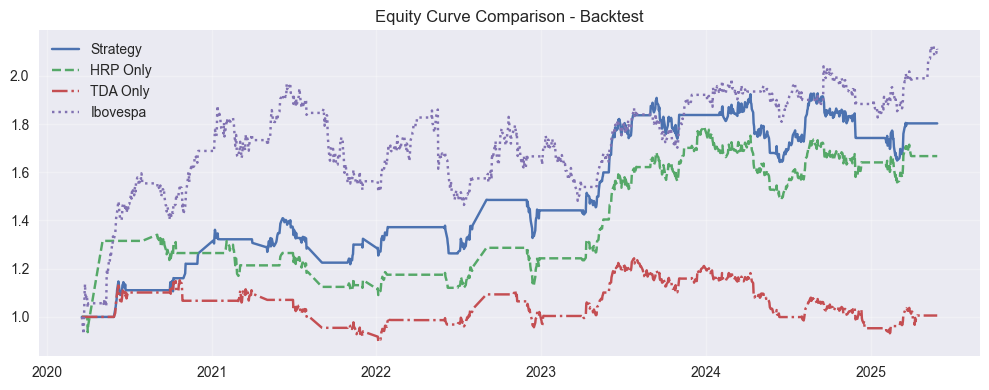

**KPIs - Backtest (Strategy vs HRP Only vs TDA Only vs Ibovespa)**

,CAGR,Sharpe,Sortino,Vol,MaxDD,Calmar,HitRate,Turnover
Strategy,0.139914,0.973837,1.123483,0.145425,-0.146255,0.95664,0.52952,0.0168
HRP Only,0.120254,0.605933,0.978972,0.224576,-0.186557,0.644598,0.520339,0.015809
TDA Only,0.001276,0.07921,0.084462,0.140025,-0.250296,0.005098,0.509804,0.013746
Ibovespa,0.180296,0.846098,1.153875,0.22607,-0.254772,0.707673,0.516129,<NA>


Comparacao salva em: C:\Users\Cockles\Documents\GitHub\itau-quant-challenge-2025\reports\equity_curve_comparison.png


In [6]:
from copy import deepcopy
from backtest.engine import run_backtest
from reports import plot_equity_curves, table_kpis

rolling_cfg = (cfg.get('backtest', {}) or {}).get('rolling_training', {}) or {}
if rolling_cfg.get('enabled'):
    is_days = rolling_cfg.get('in_sample_days', rolling_cfg.get('train_days', '??'))
    oos_days = rolling_cfg.get('out_of_sample_days', rolling_cfg.get('test_days', '??'))
    print(f'Rolling backtest ativo: {is_days} dias in-sample / {oos_days} dias out-of-sample')

bt = run_backtest(cfg, panel=panel)
equity = bt['equity_curve']
returns = equity.pct_change().dropna()

hrp_cfg = deepcopy(cfg)
hrp_portfolio = hrp_cfg.setdefault('portfolio', {})
hrp_portfolio['method'] = 'hrp_only'
hrp_portfolio.setdefault('hrp_only_regime_value', 0.5)

tda_cfg = deepcopy(cfg)
tda_cfg.setdefault('portfolio', {})['method'] = 'tda_only'

bt_hrp = run_backtest(hrp_cfg, panel=panel)
equity_hrp = bt_hrp['equity_curve']
returns_hrp = equity_hrp.pct_change().dropna()

bt_tda = run_backtest(tda_cfg, panel=panel)
equity_tda = bt_tda['equity_curve']
returns_tda = equity_tda.pct_change().dropna()

ibov_path = (ROOT / 'data' / 'benchmark' / 'ibovespa_index_b3.csv').resolve()
ibov_prices = (
    pd.read_csv(ibov_path, parse_dates=['date'], index_col='date')['close']
    .sort_index()
)
ibov_prices_aligned = ibov_prices.reindex(equity.index).ffill()
if ibov_prices_aligned.isna().all():
    raise ValueError('Ibovespa benchmark does not overlap with backtest dates.')
ibov_equity = (ibov_prices_aligned / ibov_prices_aligned.iloc[0]).rename('Ibovespa')
ibov_returns = ibov_equity.pct_change().fillna(0.0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(equity.index, equity.values, label='Strategy')
ax.plot(equity_hrp.index, equity_hrp.values, label='HRP Only', linestyle='--')
ax.plot(equity_tda.index, equity_tda.values, label='TDA Only', linestyle='-.')
ax.plot(ibov_equity.index, ibov_equity.values, label='Ibovespa', linestyle=':')
ax.set_title('Equity Curve Comparison - Backtest')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

kpi = table_kpis({
    'Strategy': {
        'equity_curve': equity,
        'returns': returns,
        'weights': bt.get('daily_positions')
    },
    'HRP Only': {
        'equity_curve': equity_hrp,
        'returns': returns_hrp,
        'weights': bt_hrp.get('daily_positions')
    },
    'TDA Only': {
        'equity_curve': equity_tda,
        'returns': returns_tda,
        'weights': bt_tda.get('daily_positions')
    },
    'Ibovespa': {
        'equity_curve': ibov_equity,
        'returns': ibov_returns,
        'weights': None
    }
})
display(Markdown('**KPIs - Backtest (Strategy vs HRP Only vs TDA Only vs Ibovespa)**'))
display(kpi)

comparison_png = plot_equity_curves(
    {
        'Strategy': equity,
        'HRP Only': equity_hrp,
        'TDA Only': equity_tda,
        'Ibovespa': ibov_equity,
    },
    filename='equity_curve_comparison.png'
)
print('Comparacao salva em:', comparison_png)

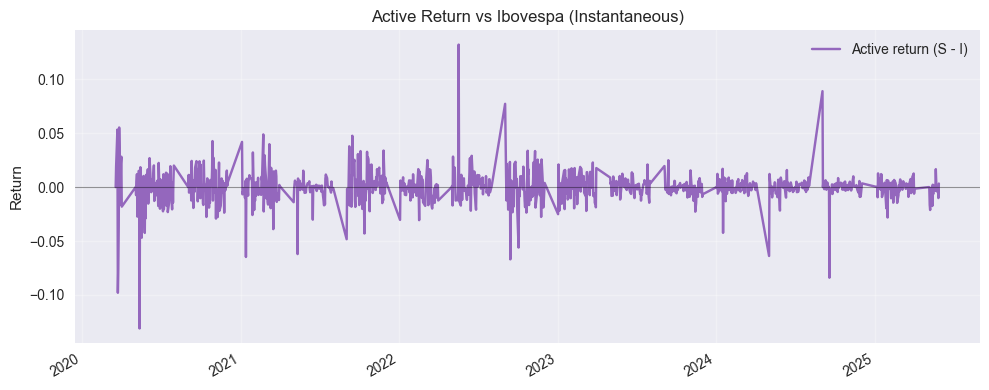

,value
CAGR_Strategy,0.163975
CAGR_Ibov,0.211920
Excess_CAGR,-0.047945
Alpha_ann,0.115639
Beta,0.217690
TrackingError,0.240194
InformationRatio,-0.240923
MaxDD_Strategy,-0.144569
MaxDD_Ibov,-0.254772
MonthlyHitRate,0.539683


In [7]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

try:
    ibov_series = ibov_prices.copy()
except NameError:
    project_root = Path.cwd().resolve().parent
    ibov_path = project_root / 'data' / 'benchmark' / 'ibovespa_index_b3.csv'
    ibov_series = (
        pd.read_csv(ibov_path, parse_dates=['date'], index_col='date')['close']
        .sort_index()
    )

idx = equity.index.intersection(ibov_series.index)
if idx.empty:
    raise ValueError('Ibovespa series does not overlap with strategy equity dates.')

eq = equity.loc[idx].ffill()
ib_prices = ibov_series.loc[idx].ffill()

try:
    ib = ibov_equity.reindex(idx).ffill()
except NameError:
    ib = (ib_prices / ib_prices.iloc[0]).rename('Ibovespa')

r_s = eq.pct_change().fillna(0.0)
try:
    r_b = ibov_returns.reindex(idx).fillna(0.0)
except NameError:
    r_b = ib.pct_change().fillna(0.0)
r_ex = r_s - r_b

ann = 252
te = r_ex.std(ddof=0) * np.sqrt(ann)
ir = (r_ex.mean() / r_ex.std(ddof=0)) * np.sqrt(ann) if r_ex.std(ddof=0) > 0 else np.nan
beta = (r_s.cov(r_b) / r_b.var()) if r_b.var() > 0 else np.nan
alpha_ann = (r_s.mean() - beta * r_b.mean()) * ann if beta == beta else np.nan

cagr_s = (eq.iloc[-1] / eq.iloc[0]) ** (ann / len(r_s)) - 1
cagr_b = (ib.iloc[-1] / ib.iloc[0]) ** (ann / len(r_b)) - 1
dd_s = (eq / eq.cummax() - 1.0).min()
dd_b = (ib / ib.cummax() - 1.0).min()
hit_m = (r_s.resample('M').sum() > r_b.resample('M').sum()).mean()

active_inst = r_ex
ax = active_inst.plot(figsize=(10, 4), color='tab:purple', label='Active return (S - I)')
ax.axhline(0.0, color='black', lw=0.8, alpha=0.4)
ax.set_title('Active Return vs Ibovespa (Instantaneous)')
ax.set_ylabel('Return')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


summary = pd.Series({
    'CAGR_Strategy': cagr_s,
    'CAGR_Ibov': cagr_b,
    'Excess_CAGR': cagr_s - cagr_b,
    'Alpha_ann': alpha_ann,
    'Beta': beta,
    'TrackingError': te,
    'InformationRatio': ir,
    'MaxDD_Strategy': dd_s,
    'MaxDD_Ibov': dd_b,
    'MonthlyHitRate': hit_m,
}).to_frame('value')
display(summary)

## Walk-Forward Validation
Executa validacao walk-forward (2 anos in-sample / 6 meses out-of-sample). Mostra equity e KPIs agregados.

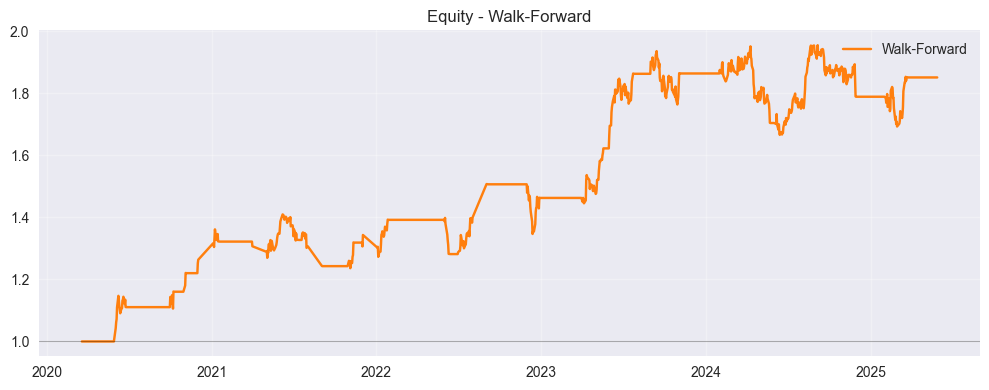

**KPIs - Walk-Forward**

,Valor
CAGR,0.146672
Sharpe,1.015841
Sortino,1.165666
Vol,0.145069
MaxDD,-0.146255
AvgTimeUnderWater,39.363636
MaxTimeUnderWater,230.000000
Calmar,1.002848
HitRate,0.531481
Turnover,0.016800


**Janelas Walk-Forward (amostra)**

,is_start,is_end,oos_start,oos_end,kpis,config,meta
0,2017-09-04,2020-03-18,2020-03-19,2020-11-16,"{'final_equity': 1.2202451927448072, 'total_re...","{'alphas': ['momentum', 'quality', 'carry'], '...","{'start': '2017-09-04T00:00:00', 'end': '2020-..."
1,2018-05-14,2020-11-16,2020-11-17,2021-07-16,"{'final_equity': 1.087697635228251, 'total_ret...","{'alphas': ['momentum', 'quality', 'carry'], '...","{'start': '2018-05-14T00:00:00', 'end': '2021-..."
2,2018-12-14,2021-07-16,2021-07-19,2022-03-18,"{'final_equity': 1.0338699393712398, 'total_re...","{'alphas': ['momentum', 'quality', 'carry'], '...","{'start': '2018-12-14T00:00:00', 'end': '2022-..."
3,2019-07-23,2022-03-18,2022-03-21,2022-11-16,"{'final_equity': 1.0823255526073892, 'total_re...","{'alphas': ['momentum', 'quality', 'carry'], '...","{'start': '2019-07-23T00:00:00', 'end': '2022-..."
4,2020-03-19,2022-11-16,2022-11-17,2023-05-19,"{'final_equity': 1.076872446466152, 'total_ret...","{'alphas': ['momentum', 'quality', 'carry'], '...","{'start': '2020-03-19T00:00:00', 'end': '2023-..."


In [8]:
from validation import run_walk_forward

wf = run_walk_forward(cfg, panel)
walk_equity = wf['equity_curve']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(walk_equity.index, walk_equity.values, color='#ff7f0e', label='Walk-Forward')
ax.axhline(1.0, color='black', linewidth=0.8, alpha=0.3)
ax.set_title('Equity - Walk-Forward')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

display(Markdown('**KPIs - Walk-Forward**'))
display(pd.DataFrame(wf['kpis'], index=['Valor']).T)

windows_df = pd.DataFrame(wf['windows'])
display(Markdown('**Janelas Walk-Forward (amostra)**'))
display(windows_df.head())

### Funcoes auxiliares para grids customizados
Utilidades genericas para montar grids 2D de parametros (kill switch, caps do HRP, etc.), extraindo metricas financeiras e salvando os artefatos em `reports/parameter_sweeps`.

In [9]:
from reports.heatmaps import run_two_param_heatmaps, run_param_grid

reports_dir = REPORTS_DIR / 'parameter_sweeps'
reports_dir.mkdir(parents=True, exist_ok=True)


## TDA - Heatmaps de Sensibilidade
Explora combinacoes dos hiperparametros de `tda_ph` e `mapper`. Cada grid roda o backtest com os novos parametros e renderiza as figuras diretamente aqui para comparacao rapida.

In [6]:
tda_grids = [
    
    #"name": "tda_ph.alert_sigma vs tda_ph.riskoff_sigma", "grid": {"tda_ph.alert_sigma":  [0.514, 0.570, 0.596, 0.622], "tda_ph.riskoff_sigma": [1.700, 1.737, 1.774, 1.811, 1.848, 1885]}},
    #{"name": "mapper.min_cluster_size vs mapper.eps_quantile", "grid": {"mapper.min_cluster_size": [6, 8, 10, 12, 14, 16, 18, 20, 22, 24], "mapper.eps_quantile": [0.260, 0.273, 0.292, 0.304, 0.317, 0.329, 0.342, 0.355, 0.367, 0.380]}},
    #{"name": "tda_ph.window vs tda_ph.zscore_lookback", "grid": {"tda_ph.window": [24, 25, 26, 27, 28, 29, 30, 31, 32, 33,34, 35, 36, 37, 38, 39, 40, 41, 42, 44], "tda_ph.zscore_lookback": [250, 254, 258, 262, 266, 271, 275, 279, 283, 287,292, 296, 300, 304, 308, 313, 317, 321, 325, 330]}},
    #{"name": "tda_ph.alert_sigma vs tda_ph.riskoff_sigma", "grid": {"tda_ph.alert_sigma": [1.2], "tda_ph.riskoff_sigma": [1.2, 1.4, 1.6, 1.8]}},
    {"name": "tda_ph.alert_sigma vs tda_ph.riskoff_sigma", "grid": {"tda_ph.alert_sigma": [10.58], "tda_ph.overlap": [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]}},
    #{"name": "tda_ph.window vs tda_ph.zscore_lookback", "grid": {"tda_ph.window": [30,45,60,75], "tda_ph.zscore_lookback": [150,200,250,300]}},
    #{"name": "mapper.n_cubes vs mapper.eps_quantile", "grid": {"mapper.n_cubes": [4,8,12,16], "mapper.eps_quantile": [0.1,0.18,0.24,0.36]}},
    #{"name": "mapper.n_cubes vs tda_ph.smooth_span", "grid": {"tda_ph.n_cubes": [3, 7, 11, 15], "tda_ph.smooth_span": [4, 8, 12, 16]}},
    #{"name": "tda_ph.n_cubes vs tda_ph.norm", "grid": {"tda_ph.n_cubes": [3, 7, 11, 15], "tda_ph.norm": ['l1', 'l2']}},         # heatmap ainda n aceita string
]

tda_runs = {}
for entry in tda_grids:
    name = entry["name"]
    grid = entry["grid"]
    prefix = name.replace(" ", "_").replace(".", "-").replace("/", "-")
    display(Markdown(f"**Grid {name}** - parametros {list(grid.keys())}"))
    results_df, heatmaps = run_two_param_heatmaps(
        cfg,
        panel,
        grid,
        report_prefix=f"tda_{prefix}",
        plot_metrics=("sharpe", "max_drawdown"),
    )
    tda_runs[name] = {"results": results_df, "heatmaps": heatmaps}
    display(results_df.sort_values("sharpe", ascending=False).head())
    for metric, path in heatmaps.items():
        display(Markdown(f"{metric.title()} heatmap: `{path}`"))
        display(Image(filename=str(path), width=420))

tda_summary = pd.DataFrame(
    [
        {"grid": name, "metric": metric, "path": str(path)}
        for name, payload in tda_runs.items()
        for metric, path in payload["heatmaps"].items()
    ]
)
display(Markdown("**Arquivos de heatmap (TDA)**"))
display(tda_summary)


**Grid tda_ph.alert_sigma vs tda_ph.riskoff_sigma** - parametros ['tda_ph.alert_sigma', 'tda_ph.overlap']

NameError: name 'run_two_param_heatmaps' is not defined

## Kill Switch - Sensibilidade de Parametros
Varre combinacoes relevantes dos limites de drawdown/vol e da janela de monitoramento para verificar impacto em Sharpe e MaxDD.

In [ ]:
import numpy as np

# Atualize os valores *_star apos cada heatmap sequencial
mdd_thres_star = -0.15  # substitua apos o heatmap 1
vol_mult_star = 1.60     # substitua apos o heatmap 2
cooldown_star = 21       # substitua apos o heatmap 3

lookback_dense = [int(round(v)) for v in np.linspace(45, 120, 20)]
mdd_thres_wide = [round(float(v), 4) for v in np.linspace(-0.12, -0.25, 20)]
vol_mult_wide = [round(float(v), 3) for v in np.linspace(1.4, 2.0, 20)]
cooldown_grid = list(range(10, 30))
mdd_thres_local = [
    round(float(v), 4)
    for v in np.linspace(mdd_thres_star - 0.02, mdd_thres_star + 0.02, 20)
]
vol_mult_local = [
    round(float(v), 3)
    for v in np.linspace(
        max(1.3, vol_mult_star - 0.10),
        min(2.1, vol_mult_star + 0.10),
        20,
    )
]
cooldown_local = [
    int(round(v))
    for v in np.linspace(
        max(8, cooldown_star - 4),
        min(35, cooldown_star + 4),
        20,
    )
]
reentry_grid = [round(float(v), 4) for v in np.linspace(0.03, 0.08, 20)]

kill_switch_grids = {
    '01_lookback_vs_thres': {
        'risk.mdd_lookback': lookback_dense,
        'risk.mdd_thres': mdd_thres_wide,
    },
    '02_thres_vs_vol': {
        'risk.mdd_thres': mdd_thres_local,
        'risk.vol_mult': vol_mult_wide,
    },
    '03_vol_vs_cooldown': {
        'risk.vol_mult': vol_mult_local,
        'risk.cooldown_days': cooldown_grid,
    },
    '04_cooldown_vs_hysteresis': {
        'risk.cooldown_days': cooldown_local,
        'risk.reentry_hysteresis': reentry_grid,
    },
}

kill_switch_runs = {}
for label, grid in kill_switch_grids.items():
    prefix = f"kill_switch_{label}"
    friendly = label.replace('_', ' ').title()
    display(Markdown(f"**Grid {friendly}** - parametros {list(grid.keys())}"))
    results_df, heatmaps = run_two_param_heatmaps(
        cfg,
        panel,
        grid,
        report_prefix=prefix,
        plot_metrics=('sharpe', 'max_drawdown'),
    )
    kill_switch_runs[label] = {'results': results_df, 'heatmaps': heatmaps}
    display(results_df.sort_values('sharpe', ascending=False).head())
    for metric, path in heatmaps.items():
        display(Markdown(f"{metric.title()} heatmap: `{path}`"))
        display(Image(filename=str(path), width=420))

kill_switch_summary = pd.DataFrame(
    [
        {'grid': label, 'metric': metric, 'path': str(path)}
        for label, payload in kill_switch_runs.items()
        for metric, path in payload['heatmaps'].items()
    ]
)
display(Markdown('**Arquivos de heatmap do kill switch**'))
display(kill_switch_summary)


## Mini Heatmaps Rapidos
Executa varreduras pequenas para preencher o historico de hiperparametros rapidamente antes da analise de correlacao.

In [8]:
from reports.heatmaps import run_two_param_heatmaps
RUN_MINI_HEATMAPS = True

if RUN_MINI_HEATMAPS:
    mini_grids = {
        'risk_quick': {
            'risk.vol_mult': [1.5, 1.7],
            'risk.mdd_thres': [-0.16, -0.14],
        },
        'tda_quick': {
            'tda.window': [150, 180],
            'tda.overlap': [0.15, 0.25],
        },
        'mapper_quick': {
            'mapper.n_cubes': [4, 6],
            'mapper.overlap': [0.2, 0.4],
        },
    }
    mini_runs = {}
    for label, grid in mini_grids.items():
        prefix = f"quick_{label}"
        display(Markdown(f"**Mini grid {label}** - parametros {list(grid.keys())}"))
        results_df, heatmaps = run_two_param_heatmaps(
            cfg,
            panel,
            grid,
            report_prefix=prefix,
            plot_metrics=('sharpe',),
        )
        mini_runs[label] = {'results': results_df, 'heatmaps': heatmaps}
        display(results_df)
        for metric, path in heatmaps.items():
            display(Markdown(f"{metric.title()} heatmap: `{path}`"))
            display(Image(filename=str(path), width=280))
else:
    display(Markdown('> Mini heatmaps desativados. Ajuste RUN_MINI_HEATMAPS para executar.'))


**Mini grid risk_quick** - parametros ['risk.vol_mult', 'risk.mdd_thres']

 - Walk-forward quick_risk_quick | risk.vol_mult=1.5, risk.mdd_thres=-0.16


KeyboardInterrupt: 

## Portfolio Parameter Sweeps
Varre combinacoes maiores de parametros do bloco `portfolio` para alimentar a analise de correlacao.

In [13]:
from reports.heatmaps import run_param_grid
portfolio_grids = [
    (
        'portfolio_exposure',
        {
            'portfolio.periphery_bias_lambda': [0.0, 0.1, 0.2],
            'portfolio.expected_returns.max_tilt': [0.02, 0.03, 0.04],
            'portfolio.expected_returns.min_signal_z': [0.0, 0.5, 1.0],
        },
    ),
    (
        'portfolio_risk_regime',
        {
            'portfolio.expected_returns.risk_aversion': [1.5, 2.5, 3.5],
            'portfolio.expected_returns.regime_gate': [0.0, 0.25, 0.5],
            'portfolio.periphery_bias_lambda': [0.0, 0.15],
        },
    )
]

portfolio_runs = {}
for label, grid in portfolio_grids:
    prefix = f"portfolio_{label}"
    display(Markdown(f"**Grid {label}** - parametros {list(grid.keys())}"))
    results_df, csv_path = run_param_grid(
        cfg,
        panel,
        grid,
        report_prefix=prefix,
    )
    portfolio_runs[label] = {'results': results_df, 'csv': csv_path}
    display(Markdown(f"Resultados salvos em `{csv_path}`"))
    display(results_df.head())
    display(results_df.describe(include='all'))


**Grid portfolio_exposure** - parametros ['portfolio.periphery_bias_lambda', 'portfolio.expected_returns.max_tilt', 'portfolio.expected_returns.min_signal_z']

Resultados salvos em C:\Users\Douglas\Documents\itau-quant-challenge-2025\reports\parameter_sweeps\portfolio_portfolio_exposure_grid.csv


Resultados salvos em `C:\Users\Douglas\Documents\itau-quant-challenge-2025\reports\parameter_sweeps\portfolio_portfolio_exposure_grid.csv`

,portfolio.periphery_bias_lambda,portfolio.expected_returns.max_tilt,portfolio.expected_returns.min_signal_z,cagr,sharpe,vol,max_drawdown,calmar
0,0.0,0.02,0.0,0.016725,0.196870,0.121784,-0.229809,0.072778
1,0.0,0.02,0.5,0.015047,0.181920,0.124556,-0.229797,0.065480
2,0.0,0.02,1.0,0.047124,0.456913,0.115253,-0.180542,0.261015
3,0.0,0.03,0.0,0.107144,0.889735,0.122870,-0.147471,0.726543
4,0.0,0.03,0.5,0.111081,0.906913,0.124696,-0.147471,0.753236


,portfolio.periphery_bias_lambda,portfolio.expected_returns.max_tilt,portfolio.expected_returns.min_signal_z,cagr,sharpe,vol,max_drawdown,calmar
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,0.100000,0.030000,0.500000,0.044114,0.412491,0.119728,-0.208135,0.268853
std,0.083205,0.008321,0.416025,0.039542,0.303660,0.003776,0.052210,0.275868
min,0.000000,0.020000,0.000000,-0.002751,0.036278,0.115253,-0.296177,-0.009794
25%,0.000000,0.020000,0.000000,0.015047,0.181920,0.115253,-0.229809,0.065480
50%,0.100000,0.030000,0.500000,0.047124,0.456913,0.119252,-0.180542,0.261015
75%,0.200000,0.040000,1.000000,0.047124,0.456913,0.122870,-0.180542,0.261015
max,0.200000,0.040000,1.000000,0.111081,0.906913,0.124696,-0.147471,0.753236


**Grid portfolio_risk_regime** - parametros ['portfolio.expected_returns.risk_aversion', 'portfolio.expected_returns.regime_gate', 'portfolio.periphery_bias_lambda']

Resultados salvos em C:\Users\Douglas\Documents\itau-quant-challenge-2025\reports\parameter_sweeps\portfolio_portfolio_risk_regime_grid.csv


Resultados salvos em `C:\Users\Douglas\Documents\itau-quant-challenge-2025\reports\parameter_sweeps\portfolio_portfolio_risk_regime_grid.csv`

,portfolio.expected_returns.risk_aversion,portfolio.expected_returns.regime_gate,portfolio.periphery_bias_lambda,cagr,sharpe,vol,max_drawdown,calmar
0,1.5,0.00,0.00,0.107144,0.889735,0.122870,-0.147471,0.726543
1,1.5,0.00,0.15,0.107144,0.889735,0.122870,-0.147471,0.726543
2,1.5,0.25,0.00,0.091009,0.768992,0.123078,-0.104596,0.870102
3,1.5,0.25,0.15,0.091009,0.768992,0.123078,-0.104596,0.870102
4,1.5,0.50,0.00,0.052154,0.487237,0.118728,-0.180542,0.288872


,portfolio.expected_returns.risk_aversion,portfolio.expected_returns.regime_gate,portfolio.periphery_bias_lambda,cagr,sharpe,vol,max_drawdown,calmar
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000
mean,2.500000,0.250000,0.075000,0.083436,0.715321,0.121559,-0.144203,0.628506
std,0.840168,0.210042,0.077174,0.023749,0.173534,0.002062,0.031992,0.254372
min,1.500000,0.000000,0.000000,0.052154,0.487237,0.118728,-0.180542,0.288872
25%,1.500000,0.000000,0.000000,0.052154,0.487237,0.118728,-0.180542,0.288872
50%,2.500000,0.250000,0.075000,0.091009,0.768992,0.122870,-0.147471,0.726543
75%,3.500000,0.500000,0.150000,0.107144,0.889735,0.123078,-0.104596,0.870102
max,3.500000,0.500000,0.150000,0.107144,0.889735,0.123078,-0.104596,0.870102


## Windows e Universo Sweeps
Gera combinacoes maiores para os parametros `windows` e `universe`, alimentando o log para correlacao.

In [ ]:
windows_grid = {
    'windows.vol_window': [30, 60, 90, 120],
    'windows.atr_len': [30, 60, 90, 120],
}

universe_grids = [
    (
        'universe_liquidity',
        {
            'universe.top_n': [15, 20, 25],
            'universe.adv_min': [300_000.0, 500_000.0, 800_000.0],
            'universe.price_min': [3.0, 5.0, 8.0],
        },
    ),
    (
        'universe_maturity',
        {
            'universe.age_min': [10, 20, 40, 60],
            'universe.hysteresis_rebalances': [2, 4, 6, 8],
        },
    ),
]

display(Markdown(f"**Grid windows** - parametros {list(windows_grid.keys())}"))
windows_results, windows_csv = run_param_grid(
    cfg,
    panel,
    windows_grid,
    report_prefix='windows_full',
)
display(Markdown(f'Total de execucoes: **{len(windows_results)}**'))
display(Markdown(f'Resultados salvos em `{windows_csv}`'))
display(windows_results.head())
display(windows_results.describe())

universe_runs = {}
for label, grid in universe_grids:
    prefix = f'universe_{label}'
    display(Markdown(f"**Grid {label}** - parametros {list(grid.keys())}"))
    results_df, csv_path = run_param_grid(
        cfg,
        panel,
        grid,
        report_prefix=prefix,
    )
    universe_runs[label] = {'results': results_df, 'csv': csv_path}
    display(Markdown(f'Total de execucoes: **{len(results_df)}**'))
    display(Markdown(f'Resultados salvos em `{csv_path}`'))
    display(results_df.head())
    display(results_df.describe())


## Correlacao de Hiperparametros
Analisa o historico de execucoes registradas e gera heatmaps de correlacao para blocos de parametros.

**Execucoes registradas:** 61 | Colunas uteis: 18

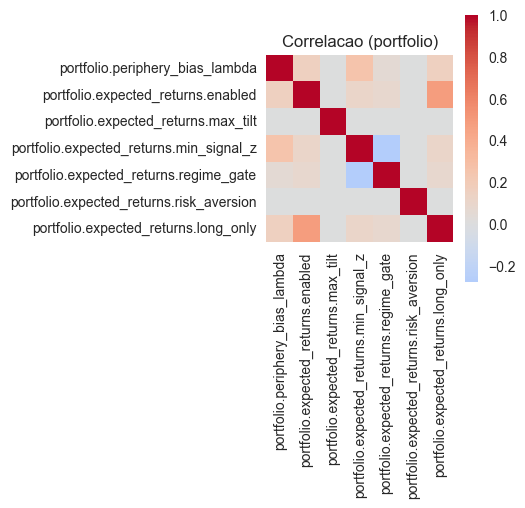

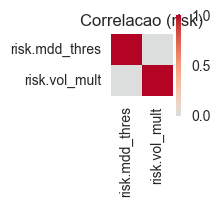

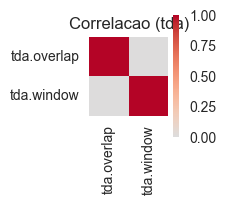

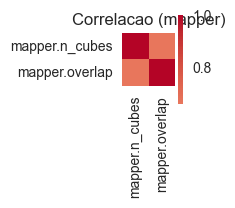

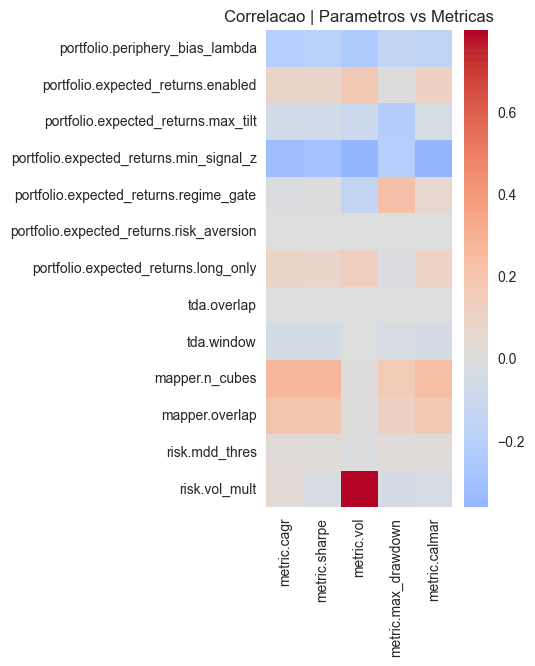

In [12]:
import seaborn as sns
from reports.correlation_dataset import (
    load_run_history,
    prepare_numeric_features,
    filter_columns_by_prefix,
)

correlation_dir = REPORTS_DIR / 'correlations'
correlation_dir.mkdir(parents=True, exist_ok=True)

try:
    run_history = load_run_history()
except FileNotFoundError as exc:
    display(Markdown(f'> Atencao: {exc}'))
else:
    numeric_history = prepare_numeric_features(run_history, include_metrics=True)
    display(Markdown(f"**Execucoes registradas:** {len(numeric_history)} | Colunas uteis: {numeric_history.shape[1]}"))
    metric_cols = [col for col in numeric_history.columns if col.startswith('metric.')]
    param_cols = [col for col in numeric_history.columns if not col.startswith('metric.') and not col.startswith('meta.')]
    parameter_df = numeric_history.loc[:, param_cols]
    correlation_map = {
        'portfolio': 'portfolio.',
        'risk': 'risk.',
        'tda': 'tda.',
        'tda_ph': 'tda_ph.',
        'mapper': 'mapper.',
        'factors': 'factors.',
        'validation': 'validation.',
    }
    generated = []
    for label, prefix in correlation_map.items():
        subset = filter_columns_by_prefix(parameter_df, prefix)
        if subset.shape[1] < 2:
            continue
        corr = subset.corr()
        corr.to_csv(correlation_dir / f'correlation_{label}.csv')
        fig, ax = plt.subplots(figsize=(min(10, 1 + 0.6 * subset.shape[1]), min(10, 1 + 0.6 * subset.shape[1])))
        sns.heatmap(corr, cmap='coolwarm', center=0, square=True, ax=ax)
        ax.set_title(f'Correlacao ({label})')
        plt.tight_layout()
        display(fig)
        plt.close(fig)
        generated.append(label)
    if metric_cols and parameter_df.shape[1] > 1:
        joint_cols = param_cols + metric_cols
        joint_df = numeric_history.loc[:, joint_cols]
        corr = joint_df.corr().loc[param_cols, metric_cols]
        corr.to_csv(correlation_dir / 'correlation_params_vs_metrics.csv')
        fig, ax = plt.subplots(figsize=(min(10, 1 + 0.4 * len(metric_cols)), min(10, 1 + 0.4 * len(param_cols))))
        sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax)
        ax.set_title('Correlacao | Parametros vs Metricas')
        plt.tight_layout()
        display(fig)
        plt.close(fig)
    if not generated:
        display(Markdown('> Nenhum bloco com variancia suficiente para calcular correlacao.'))


## HRP e Caps - Sensibilidade
Analisa como caps de participacao/cluster e metas de risco influenciam a carteira, facilitando comparacao com as curvas de kill switch.

In [ ]:
hrp_grids = {
    "participation_vs_cluster": {
        "risk.participation_cap": [0.03, 0.04, 0.05],
        "risk.max_cluster_regime.high": [0.08, 0.10, 0.12],
    },
    "target_vol_vs_turnover": {
        "risk.target_vol": [0.08, 0.10, 0.12],
        "risk.turnover_cap": [0.15, 0.25, 0.35],
    },
}

hrp_runs = {}
for label, grid in hrp_grids.items():
    prefix = f"hrp_{label}"
    friendly = label.replace("_", " " ).title()
    display(Markdown(f"**Grid {friendly}** - parametros {list(grid.keys())}"))
    results_df, heatmaps = run_two_param_heatmaps(
        cfg,
        panel,
        grid,
        report_prefix=prefix,
        plot_metrics=("sharpe", "max_drawdown")
    )
    hrp_runs[label] = {"results": results_df, "heatmaps": heatmaps}
    display(results_df.sort_values("sharpe", ascending=False).head())
    for metric, path in heatmaps.items():
        display(Markdown(f"{metric.title()} heatmap: `{path}`"))
        display(Image(filename=str(path), width=420))

hrp_summary = pd.DataFrame(
    [
        {"grid": label, "metric": metric, "path": str(path)}
        for label, payload in hrp_runs.items()
        for metric, path in payload["heatmaps"].items()
    ]
)
display(Markdown("**Arquivos de heatmap (HRP / caps)**"))
display(hrp_summary)


## Grid Integrado de Risco
Combina target de volatilidade e limite de drawdown para avaliar consistencia das configuracoes recomendadas.

In [ ]:
combined_grid = {
    "risk.target_vol": [0.07, 0.08, 0.09],
    "risk.mdd_thres": [-0.10, -0.12, -0.14],
}

display(Markdown(f"**Grid integrado** - parametros {list(combined_grid.keys())}"))
combined_results, combined_heatmaps = run_two_param_heatmaps(
    cfg,
    panel,
    combined_grid,
    report_prefix="risk_combo",
    plot_metrics=("sharpe", "max_drawdown")
)
display(combined_results.sort_values("sharpe", ascending=False).head())
combined_summary = pd.DataFrame(
    [
        {"metric": metric, "path": str(path)}
        for metric, path in combined_heatmaps.items()
    ]
)
display(Markdown("**Arquivos de heatmap (grid integrado)**"))
display(combined_summary)
for metric, path in combined_heatmaps.items():
    display(Markdown(f"{metric.title()} heatmap: `{path}`"))
    display(Image(filename=str(path), width=420))


## Relatorio PDF (Opcional)
Gera um PDF consolidado com figuras e caminhos dos artefatos.

In [ ]:
# from reports.build_pdf import build_pdf
# 
# pdf_out = REPORTS_DIR / 'consolidated_report.pdf'
# build_pdf(CONFIG_PATH, pdf_out)
# print('PDF salvo em:', pdf_out)

## Proximos Passos
- Ajuste o grid de robustez (ex.: incluir `epsilon`, `n_cubes`, `overlap`).
- Tente diferentes periodos e universos no YAML.
- Compare estrategias alterando `factors.alphas` para diferentes pesos.
